In [1]:
# ============================================================================
# TASK-SPECIFIC ANALYSIS NOTEBOOK - [TASK NAME]
# ============================================================================

# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys

# Custom analysis modules
sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models') 
import bandit_plots as bp
import bandit_preprocessing as bpp

sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models/bandit_models')
import plot_models_v_mouse as plots
import conditional_probs as cp

# Plotting settings
%matplotlib inline
sns.set(style='ticks', font_scale=1.6, rc={'axes.labelsize':18, 'axes.titlesize':18}) 

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Cell 2: Load Master Data
OUTPUT_DIR = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data/'
master_output_file = os.path.join(OUTPUT_DIR, 'Master_All_Animals_Preprocessed_updated.csv')
df_master = pd.read_csv(master_output_file)

print(f"Master data loaded: {df_master.shape}")
print(f"Date range: {df_master['Date'].min()} to {df_master['Date'].max()}")

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_45878/1348531088.py:4: DtypeWarning: Columns (34,38,40,69,70,72,74,83,84,89,90,95,98,103,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df_master = pd.read_csv(master_output_file)


Master data loaded: (338861, 115)
Date range: 2020-12-15 to 2024-03-25


In [3]:
df_master.columns.unique()

Index(['Trial', 'BlockCount', 'TrialWithinBlock', 'Block', 'Condition',
       'TrialError', 'ReactionTime', 'AbsoluteTrialStartTime', 'Year', 'Month',
       ...
       'Num_Cued_Transitions_x.1', 'Has_Cued_Transitions_x.1',
       'Session_Type_y.1', 'Num_Reversals_y.1', 'Num_Cued_Transitions_y.1',
       'Has_Cued_Transitions_y.1', 'Session_Type', 'Num_Reversals',
       'Num_Cued_Transitions', 'Has_Cued_Transitions'],
      dtype='object', length=115)

In [4]:
# Define the classification function for the different types of reversasl sessions (2-ABT vs mixed)
def classify_reversal_session(session_df):
    """Classify a Reversal task session by its transition structure"""
    if session_df['Task_Type'].iloc[0] != 'Reversal':
        return {
            'Session_Type': None,
            'Num_Reversals': None,
            'Num_Cued_Transitions': None,
            'Has_Cued_Transitions': None
        }
    
    blocks = sorted(session_df['Block'].unique())
    
    # Count reversals and cued transitions
    reversals = 0
    cued_transitions = 0
    
    for i in range(len(blocks) - 1):
        current = blocks[i]
        next_block = blocks[i + 1]
        
        if next_block == current + 1:
            if current % 2 == 1:  # Odd→Even (1→2, 3→4, etc) = Reversal
                reversals += 1
            else:  # Even→Odd (2→3, 4→5, etc) = Cued Transition
                cued_transitions += 1
    
    # Classify session type
    if cued_transitions == 0:
        session_type = '2-ABT'  # Pure reversal learning, no location changes
    else:
        session_type = 'mixed'  # Has both reversals AND cued transitions
    
    return {
        'Session_Type': session_type,
        'Num_Reversals': reversals,
        'Num_Cued_Transitions': cued_transitions,
        'Has_Cued_Transitions': cued_transitions > 0
    }

print("Function defined!")


Function defined!


In [5]:
df_master

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,Day,Hour,Minute,Second,BehavioralCodes,ObjectStatusRecord,RewardRecord,VariableChanges,CycleRate_1,CycleRate_2,Ver,Target1_name,Target1_x,Target1_y,Target1_xsize,Target1_ysize,Target1_path,Target2_name,Target2_x,Target2_y,Target2_xsize,Target2_ysize,Target2_path,RewardVolume,RewardType,BlockLength,RandomValue,Block_Prob,StimuliChosen,ProbReward,Reward,Animal_Name,Session_Filename,CodeTimes_1,CodeTimes_2,CodeTimes_3,CodeTimes_4,CodeNumbers_1,CodeNumbers_2,CodeNumbers_3,CodeNumbers_4,StartTimes,EndTimes,reward_dur,EyeOffset_1,EyeOffset_2,Eye2Offset_1,Eye2Offset_2,CodeTimes_5,CodeTimes_6,CodeTimes_7,CodeNumbers_5,CodeNumbers_6,CodeNumbers_7,Date,Outcome,Target1_location,Target2_location,Session_ID,PhysicalChoice,PrevPhysicalChoice,PhysicalSwitch,prob_Condition,Task_Type,TaskObject1_Type,TaskObject1_Size_1,TaskObject1_Size_2,TaskObject1_Color_1,TaskObject1_Color_2,TaskObject1_Color_3,TaskObject1_Fill,TaskObject1_LocX,TaskObject1_LocY,TaskObject2_Type,TaskObject2_Source,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Session_Type_x,Num_Reversals_x,Num_Cued_Transitions_x,Has_Cued_Transitions_x,Session_Type_y,Num_Reversals_y,Num_Cued_Transitions_y,Has_Cued_Transitions_y,Session_Type_x.1,Num_Reversals_x.1,Num_Cued_Transitions_x.1,Has_Cued_Transitions_x.1,Session_Type_y.1,Num_Reversals_y.1,Num_Cued_Transitions_y.1,Has_Cued_Transitions_y.1,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions
0,1,1,1,1,1,6,NaN,0.000000e+00,2021,10,15,12,28,40.427,NaN,NaN,NaN,NaN,49.9975,32.9957,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,NaN,NaN,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
1,2,1,2,1,1,6,NaN,6.885500e+04,2021,10,15,12,29,49.282,NaN,NaN,NaN,NaN,33.3844,11.3957,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,BottomLeft,0.0,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
2,3,1,3,1,1,6,NaN,8.553550e+04,2021,10,15,12,30,5.962,NaN,NaN,NaN,NaN,33.3318,7.7382,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,BottomLeft,0.0,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
3,4,1,4,1,1,0,NaN,9.276853e+04,2021,10,15,12,30,13.195,NaN,NaN,NaN,NaN,33.3414,5.9564,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L..

In [6]:
# Apply the function to all sessions
print("Adding Reversal metadata columns...")

# Group by session and apply classification
session_metadata = df_master.groupby('Session_ID').apply(classify_reversal_session).apply(pd.Series)
session_metadata = session_metadata.reset_index()

# Merge back to main dataframe
df_master = df_master.merge(session_metadata, on='Session_ID', how='left')

print("Done! New columns added:")
print(df_master[['Session_ID', 'Task_Type', 'Session_Type_y', 'Num_Reversals_y', 'Num_Cued_Transitions_y']].head(20))

Adding Reversal metadata columns...


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_45878/644912999.py:9: FutureWarning: Passing 'suffixes' which cause duplicate columns {'Session_Type_x', 'Has_Cued_Transitions_x', 'Num_Reversals_x', 'Num_Cued_Transitions_x'} in the result is deprecated and will raise a MergeError in a future version.
  df_master = df_master.merge(session_metadata, on='Session_ID', how='left')


Done! New columns added:
                                           Session_ID  Task_Type  \
0   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
1   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
2   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
3   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
4   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
5   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
6   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
7   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
8   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
9   2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
10  2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
11  2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
12  2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...  WhereTask   
13  2021-10-15_20211015

In [13]:
df_master['Session_Type_x']

,Session_Type_x,Session_Type_x
0,NaN,Single_Block
1,NaN,Single_Block
2,NaN,Single_Block
3,NaN,Single_Block
4,NaN,Single_Block
...,...,...
338856,2-ABT,2-ABT
338857,2-ABT,2-ABT
338858,2-ABT,2-ABT
338859,2-ABT,2-ABT


In [ ]:
# Check the results for Reversal task
df_master['Session_Type'] = df_master['Session_Type_y']
print("=== Reversal Session Type Distribution ===\n")
reversal_sessions = df_master[df_master['Task_Type'] == 'Reversal'].groupby('Session_ID').first()
print(reversal_sessions['Session_Type'].value_counts())

print("\n=== By Probability Condition ===")
print(reversal_sessions.groupby('prob_Condition')['Session_Type'].value_counts())

ValueError: Cannot set a DataFrame with multiple columns to the single column Session_Type

In [32]:
#Save the enhanced dataframe (optional but recommended)
output_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_master_merged_data_with_metadata.csv'
df_master.to_csv(output_path, index=False)
print(f"Enhanced dataframe saved to: {output_path}")

Enhanced dataframe saved to: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_master_merged_data_with_metadata.csv


In [53]:
def classify_reversal_session(session_df):
    """Classify ANY session by its transition structure"""
    
    # Check if we have Block column
    if 'Block' not in session_df.columns:
        return {
            'Session_Type': 'Unknown',
            'Num_Reversals': None,
            'Num_Cued_Transitions': None,
            'Has_Cued_Transitions': None
        }
    
    blocks = sorted(session_df['Block'].unique())
    
    # Need at least 2 blocks to have transitions
    if len(blocks) < 2:
        return {
            'Session_Type': 'Single_Block',
            'Num_Reversals': 0,
            'Num_Cued_Transitions': 0,
            'Has_Cued_Transitions': False
        }
    
    # Count reversals and cued transitions
    reversals = 0
    cued_transitions = 0
    
    for i in range(len(blocks) - 1):
        current = blocks[i]
        next_block = blocks[i + 1]
        
        if next_block == current + 1:
            if current % 2 == 1:  # Odd→Even (1→2, 3→4, etc) = Reversal
                reversals += 1
            else:  # Even→Odd (2→3, 4→5, etc) = Cued Transition
                cued_transitions += 1
    
    # Classify session type based on structure
    if reversals == 0 and cued_transitions == 0:
        session_type = 'No_Transitions'
    elif cued_transitions == 0:
        session_type = '2-ABT'  # Pure reversal learning
    elif reversals > 0 and cued_transitions > 0:
        session_type = 'Mixed'  # Has both reversals AND cued transitions
    else:  # Only cued transitions, no reversals
        session_type = 'Cued_Only'
    
    return {
        'Session_Type': session_type,
        'Num_Reversals': reversals,
        'Num_Cued_Transitions': cued_transitions,
        'Has_Cued_Transitions': cued_transitions > 0
    }

print("Updated function defined!")

Updated function defined!


In [54]:
import pandas as pd

# Create summary table
summary = pd.DataFrame({
    'Num_Sessions': df_master.groupby(['Task_Type', 'Session_Type'])['Session_ID'].nunique(),
    'Num_Trials': df_master.groupby(['Task_Type', 'Session_Type']).size(),
})
summary['Avg_Trials_per_Session'] = (summary['Num_Trials'] / summary['Num_Sessions']).round(1)

print("\nComplete breakdown:")
print(summary)


Complete breakdown:
                                    Num_Sessions  Num_Trials  \
Task_Type           Session_Type                               
Reversal            2-ABT                    169       53042   
                    Cued_Only                  2          83   
                    Mixed                    190       51115   
                    No_Transitions             4         314   
                    Single_Block              21         317   
Reversal_SetChanges 2-ABT                     15        3326   
                    Mixed                     98       31156   
                    Single_Block               3          51   
Shaping             Cued_Only                  3        2532   
                    Mixed                      6        5134   
                    Single_Block               3        2195   
WhatTask            2-ABT                     23        8887   
                    Cued_Only                  1         296   
                   

In [55]:
master_output_file

'/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/Merged_Data/Master_All_Animals_Preprocessed_updated.csv'

In [56]:
# save the updated master file
df_master.to_csv(master_output_file, index=False)
print("✓ Master file updated")

✓ Master file updated


#   Analysis of the Single Block Sessions

In [72]:
tmp = single_block_100[single_block_100['BlockLength'] >= 100]
tmp.Animal_Name.unique()

array(['Fiona', 'Raven', 'Salmon'], dtype=object)

/Users/kevinmastro/anaconda3/envs/GLM_env/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kevinmastro/anaconda3/envs/GLM_env/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/kevinmastro/anaconda3/envs/GLM_env/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kevinmastro/anaconda3/envs/GLM_env/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


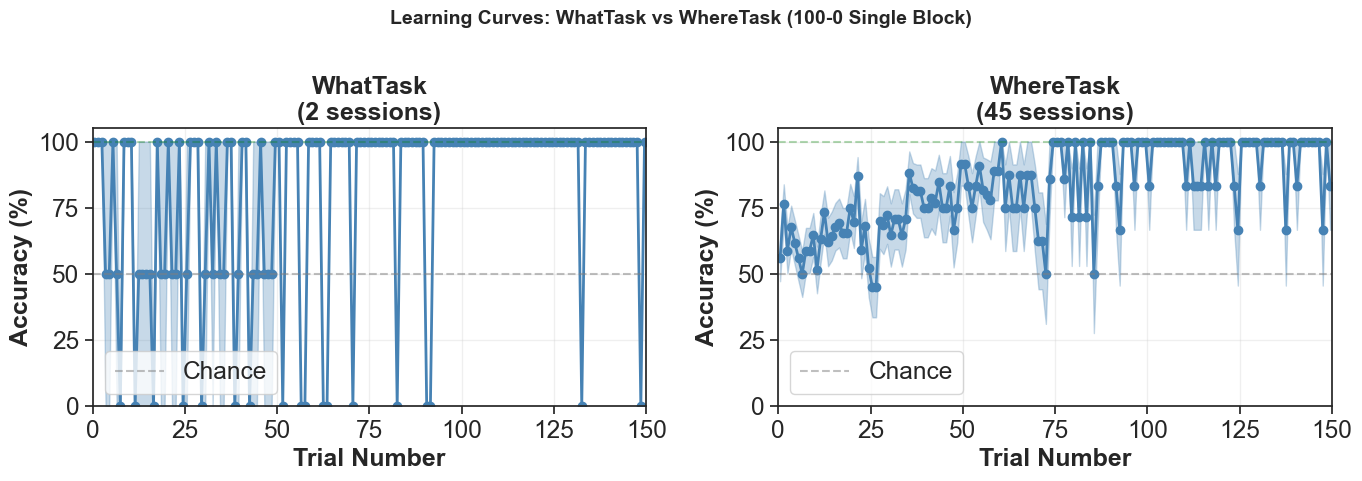

In [78]:
# 2. Learning Curves (accuracy by trial within session)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, task in enumerate(['WhatTask', 'WhereTask']):
    task_data = single_block_100[single_block_100['Task_Type'] == task].copy()
    
    if len(task_data) == 0:
        axes[idx].text(0.5, 0.5, f'No {task} data', ha='center', va='center')
        axes[idx].set_title(f'{task}')
        continue
    
    # Calculate trial-by-trial accuracy within each session
    session_curves = []
    
    for session_id in task_data['Session_ID'].unique():
        session_df = task_data[task_data['Session_ID'] == session_id].copy()
        session_df = session_df.sort_values('Trial')
        
        # Get accuracy by trial position
        if len(session_df) >= 10:  # Only use sessions with at least 10 trials
            session_df['TrialNum'] = range(len(session_df))
            session_curves.append(session_df[['TrialNum', 'Outcome']].values)
    
    if session_curves:
        # Find max trial length
        max_trials = max([len(curve) for curve in session_curves])
        
        # Bin trials and compute average
        bin_size = 1
        n_bins = max_trials // bin_size
        
        binned_accuracy = []
        binned_trials = []
        binned_sem = []
        
        for bin_idx in range(n_bins):
            bin_start = bin_idx * bin_size
            bin_end = (bin_idx + 1) * bin_size
            
            bin_outcomes = []
            for curve in session_curves:
                if len(curve) > bin_start:
                    trials_in_bin = curve[bin_start:min(bin_end, len(curve)), 1]
                    bin_outcomes.extend(trials_in_bin)
            
            if bin_outcomes:
                binned_accuracy.append(np.mean(bin_outcomes) * 100)
                binned_trials.append(bin_start + bin_size/2)
                binned_sem.append(stats.sem(bin_outcomes) * 100)
        
        # Convert to arrays for proper vectorized operations
        binned_trials = np.array(binned_trials)
        binned_accuracy = np.array(binned_accuracy)
        binned_sem = np.array(binned_sem)
        
        # Plot line
        axes[idx].plot(binned_trials, binned_accuracy, 'o-', linewidth=2, markersize=6, color='steelblue')
        axes[idx].fill_between(binned_trials, binned_accuracy - binned_sem, binned_accuracy + binned_sem, alpha=0.3, color='steelblue')
        axes[idx].axhline(50, color='gray', linestyle='--', alpha=0.5, label='Chance')
        axes[idx].axhline(100, color='green', linestyle='--', alpha=0.3)
        
        axes[idx].set_xlabel('Trial Number', fontweight='bold')
        axes[idx].set_ylabel('Accuracy (%)', fontweight='bold')
        axes[idx].set_title(f'{task}\n({task_data["Session_ID"].nunique()} sessions)', fontweight='bold')
        axes[idx].set_ylim(0, 105)
        axes[idx].set_xlim(0, 150)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()

plt.suptitle('Learning Curves: WhatTask vs WhereTask (100-0 Single Block)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

WhereTask 100-0 Single Block:
  Sessions: 45
  Animals: ['Coral', 'Fiona', 'Griffin', 'Raven', 'Salmon', 'Sunflower', 'Tuna', 'Zazu']
  Total trials: 2,317

After filtering (≥20 trials):
  Sessions: 24
  Average session length: 173.8 trials


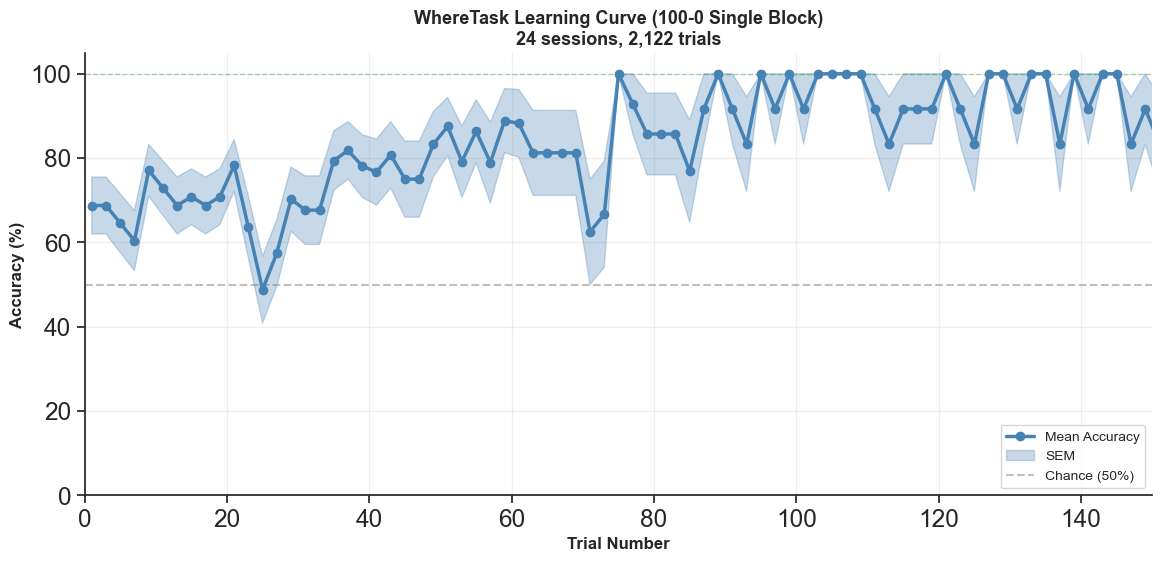

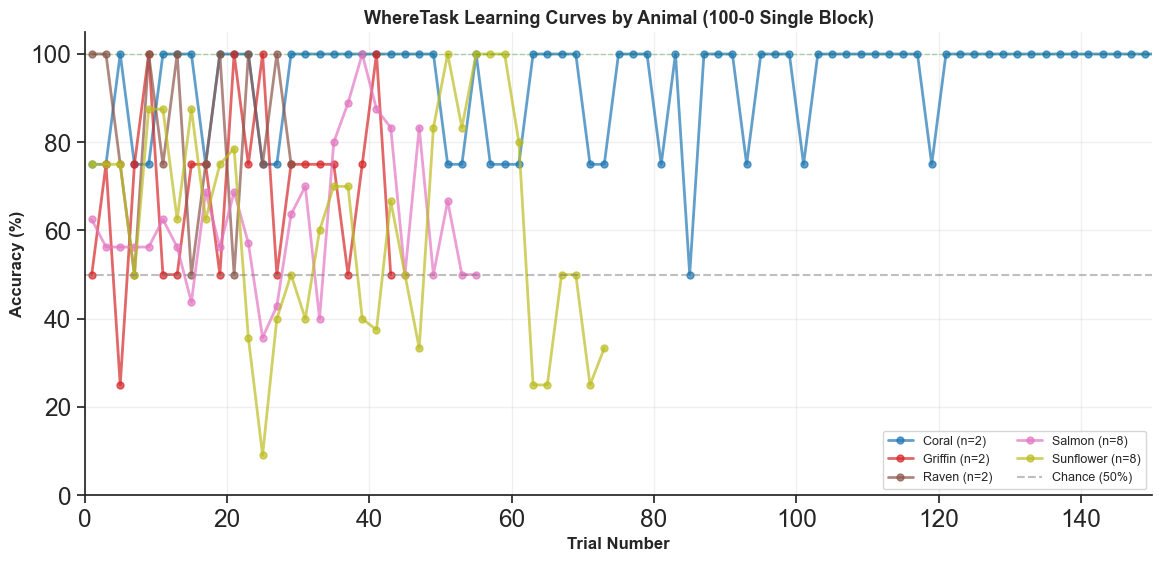


SUMMARY BY ANIMAL

Coral:
  Sessions: 2
  Trials: 361
  Overall Accuracy: 93.1%

Fiona:
  Sessions: 1
  Trials: 280
  Overall Accuracy: 90.4%

Griffin:
  Sessions: 2
  Trials: 205
  Overall Accuracy: 82.0%

Raven:
  Sessions: 2
  Trials: 87
  Overall Accuracy: 82.8%

Salmon:
  Sessions: 8
  Trials: 353
  Overall Accuracy: 61.5%

Sunflower:
  Sessions: 8
  Trials: 494
  Overall Accuracy: 71.1%

Zazu:
  Sessions: 1
  Trials: 342
  Overall Accuracy: 95.6%


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Filter for WhereTask Single_Block 100-0
where_data = df_master[
    (df_master['Task_Type'] == 'WhereTask') & 
    (df_master['Session_Type'] == 'Single_Block') & 
    (df_master['prob_Condition'] == '100-0')
].copy()

print(f"WhereTask 100-0 Single Block:")
print(f"  Sessions: {where_data['Session_ID'].nunique()}")
print(f"  Animals: {sorted(where_data['Animal_Name'].unique())}")
print(f"  Total trials: {len(where_data):,}")

if len(where_data) == 0:
    print("No data found!")
else:
    # Prepare data: normalize trial numbers within each session
    session_data = []
    
    for session_id in where_data['Session_ID'].unique():
        session_df = where_data[where_data['Session_ID'] == session_id].copy()
        session_df = session_df.sort_values('Trial')
        
        if len(session_df) >= 20:  # Only include sessions with at least 20 trials
            session_df['TrialNum'] = range(len(session_df))
            session_df['SessionLength'] = len(session_df)
            session_data.append(session_df)
    
    if not session_data:
        print("No sessions with sufficient trials found!")
    else:
        # Concatenate all sessions
        all_sessions = pd.concat(session_data, ignore_index=True)
        
        print(f"\nAfter filtering (≥20 trials):")
        print(f"  Sessions: {all_sessions['Session_ID'].nunique()}")
        print(f"  Average session length: {all_sessions['SessionLength'].mean():.1f} trials")
        
        # Find max trial number across sessions
        max_trials = all_sessions['TrialNum'].max()
        
        # Create bins for averaging
        bin_size = 2  # Average every 5 trials
        n_bins = int(np.ceil(max_trials / bin_size))
        
        # ====================================================================
        # PLOT 1: Mean learning curve with SEM shaded region
        # ====================================================================
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        bin_centers = []
        bin_means = []
        bin_sems = []
        bin_counts = []
        
        for bin_idx in range(n_bins):
            bin_start = bin_idx * bin_size
            bin_end = (bin_idx + 1) * bin_size
            
            # Get all outcomes in this bin across all sessions
            bin_trials = all_sessions[
                (all_sessions['TrialNum'] >= bin_start) & 
                (all_sessions['TrialNum'] < bin_end)
            ]
            
            if len(bin_trials) >= 5:  # Need at least 5 trials for meaningful average
                outcomes = bin_trials['Outcome'].values
                bin_centers.append(bin_start + bin_size/2)
                bin_means.append(np.mean(outcomes) * 100)
                bin_sems.append(stats.sem(outcomes) * 100)
                bin_counts.append(len(bin_trials))
        
        bin_centers = np.array(bin_centers)
        bin_means = np.array(bin_means)
        bin_sems = np.array(bin_sems)
        
        # Plot mean with shaded SEM
        ax.plot(bin_centers, bin_means, 'o-', linewidth=2.5, markersize=6, 
                color='steelblue', label='Mean Accuracy', zorder=3)
        ax.fill_between(bin_centers, 
                        bin_means - bin_sems, 
                        bin_means + bin_sems, 
                        alpha=0.3, color='steelblue', label='SEM')
        
        # Reference lines
        ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (50%)')
        ax.axhline(100, color='green', linestyle='--', alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Trial Number', fontsize=12, fontweight='bold')
        ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'WhereTask Learning Curve (100-0 Single Block)\n{all_sessions["Session_ID"].nunique()} sessions, {len(all_sessions):,} trials', 
                     fontsize=13, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xlim(-5, max_trials + 5)
        ax.set_xlim(0, 150)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower right', fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # ====================================================================
        # PLOT 2: Individual animal learning curves
        # ====================================================================
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        animals = sorted(all_sessions['Animal_Name'].unique())
        colors = plt.cm.tab10(np.linspace(0, 1, len(animals)))
        
        for idx, animal in enumerate(animals):
            animal_data = all_sessions[all_sessions['Animal_Name'] == animal]
            
            # Bin data for this animal
            animal_bin_centers = []
            animal_bin_means = []
            
            for bin_idx in range(n_bins):
                bin_start = bin_idx * bin_size
                bin_end = (bin_idx + 1) * bin_size
                
                bin_trials = animal_data[
                    (animal_data['TrialNum'] >= bin_start) & 
                    (animal_data['TrialNum'] < bin_end)
                ]
                
                if len(bin_trials) >= 3:  # Need at least 3 trials
                    animal_bin_centers.append(bin_start + bin_size/2)
                    animal_bin_means.append(np.mean(bin_trials['Outcome']) * 100)
            
            if animal_bin_centers:
                n_sessions = animal_data['Session_ID'].nunique()
                ax.plot(animal_bin_centers, animal_bin_means, 'o-', 
                       linewidth=2, markersize=5, alpha=0.7,
                       color=colors[idx], label=f'{animal} (n={n_sessions})')
        
        # Reference lines
        ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='Chance (50%)')
        ax.axhline(100, color='green', linestyle='--', alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Trial Number', fontsize=12, fontweight='bold')
        ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'WhereTask Learning Curves by Animal (100-0 Single Block)', 
                     fontsize=13, fontweight='bold')
        ax.set_ylim(0, 105)
        # ax.set_xlim(-5, max_trials + 5)
        ax.set_xlim(0, 150)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=9, ncol=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*60)
        print("SUMMARY BY ANIMAL")
        print("="*60)
        
        for animal in animals:
            animal_data = all_sessions[all_sessions['Animal_Name'] == animal]
            accuracy = animal_data['Outcome'].mean() * 100
            n_sessions = animal_data['Session_ID'].nunique()
            n_trials = len(animal_data)
            
            print(f"\n{animal}:")
            print(f"  Sessions: {n_sessions}")
            print(f"  Trials: {n_trials}")
            print(f"  Overall Accuracy: {accuracy:.1f}%")

In [85]:
# show all columns of df_master set options so that all rows are shown
pd.set_option('display.max_rows', None)
counter = 0
for session_filename in df_master['Session_Filename'].unique():
    # print the session filename and the Task_Type
    print(f"{session_filename} - {df_master[df_master['Session_Filename'] == session_filename]['Task_Type'].unique()}")
    counter += 1

print(counter)

20211015_Fiona_100%Con_WhereBlocks1.1_Easy - ['WhereTask']
20211018_Fiona_100%Con_WhereBlocks1.1_Easy - ['WhereTask']
20211019_Fiona_100%Con_WhereBlocks1.1 - ['WhereTask']
20211020_Fiona_100%Con_WhereBlocks1.2 - ['WhereTask']
20211021_Fiona_100%Con_WhereBlocks1.2 - ['WhereTask']
20211022_Fiona_100%Con_WhereBlocks1.3 - ['WhereTask']
20211101_Fiona_100%Con_WhereBlocks1.3 - ['WhereTask']
20211102_Fiona_100%Con_WhereBlocks1.4 - ['WhereTask']
20211103_Fiona_100%Con_WhereBlocks1.4 - ['WhereTask']
20211104_Fiona_100%Con_WhereBlocks1.5 - ['WhereTask']
20211105_Fiona_100%Con_WhereBlocks1.5 - ['WhereTask']
20211108_Fiona_100%Con_WhereBlocks1.6 - ['WhereTask']
20211109_Fiona_100%Con_WhereBlocks1.6 - ['WhereTask']
20211112_Fiona_100%Con_WhereBlocks1.7 - ['WhereTask']
20211115_Fiona_100%Con_WhereBlocks1.8 - ['WhereTask']
20211116_Fiona_100%Con_WhereBlocks1.9 - ['WhereTask']
20211117_Fiona_100%Con_WhereBlocks1.10 - ['WhereTask']
20211118_Fiona_100%Con_WhereBlocks1.11 - ['WhereTask']
20211119_Fiona_1